# CoNLL Iterative Run Analysis Notebook — SciBERT Log Scale

This notebook analyses the **CoNLL iterative target-injection run** using the SciBERT summary file:

```text
runs/summary_conll_scibert.csv
```

It follows the same structure and visual style as the earlier BERT analysis notebooks, but the metrics are computed from the SciBERT summary CSV instead.


## 1. Paths and data loading

In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

BG = "#f6f1eb"
TEXT = "#2f241f"
EDGE = "#3d3128"
GRID = "#8b6f5a"

DOMAIN_COLORS = {
    "ewt_dev": "#EFA6C1",
    "conll_test": "#8FD3B6",
    "astro_test": "#F4B183",
}

DOMAIN_LABELS = {
    "ewt_dev": "EWT dev",
    "conll_test": "CoNLL test",
    "astro_test": "WIESP test",
}

METRIC_LABELS = {
    "entity_f1_micro": "Entity micro F1",
    "entity_f1_macro": "Entity macro F1",
    "entity_f1_weighted": "Entity weighted F1",
    "entity_precision": "Entity precision",
    "entity_recall": "Entity recall",
    "token_acc": "Token accuracy",
    "token_f1": "Token F1",
    "eval_loss": "Evaluation loss",
    "delta_f1_vs_iter0": "Δ micro F1 vs iter 0",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": EDGE,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.size": 12,
    "axes.titleweight": "bold",
})

def finish_plot(title, xlabel=None, ylabel=None, legend=True, rotate_x=False):
    ax = plt.gca()
    ax.set_title(title, fontsize=20, fontweight="bold", color=TEXT, pad=18)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13, color=TEXT, labelpad=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13, color=TEXT, labelpad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(EDGE)
    ax.spines["bottom"].set_color(EDGE)
    ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)
    if rotate_x:
        plt.xticks(rotation=25, ha="right")
    if legend:
        leg = ax.legend(frameon=True)
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(EDGE)
    plt.tight_layout()

def add_bar_labels(ax, bars, fmt="{:.3f}", y_offset=0.01):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=10,
            color=TEXT
        )

def log_x(values):
    """log10(n + 1), keeping 0 visible at the far left."""
    return np.log10(np.asarray(values, dtype=float) + 1.0)

def apply_log_xaxis_from(df, col="n_target_examples_display"):
    ax = plt.gca()
    schedule = df.groupby("iteration")[col].first().sort_index().to_list()

    if len(schedule) <= 8:
        ticks = schedule
    else:
        idxs = np.linspace(0, len(schedule)-1, 7).round().astype(int)
        ticks = [schedule[i] for i in idxs]

    ax.set_xticks(log_x(ticks))
    ax.set_xticklabels([str(int(t)) for t in ticks], rotation=0)
    ax.set_xlim(log_x([min(schedule)])[0] - 0.03, log_x([max(schedule)])[0] + 0.03)


In [6]:
SUMMARY_PATH = Path("../../runs/summary_conll_scibert.csv")

# Fallback only for testing outside the repo
if not SUMMARY_PATH.exists() and Path("/mnt/data/summary_conll_scibert.csv").exists():
    SUMMARY_PATH = Path("/mnt/data/summary_conll_scibert.csv")

print("SUMMARY_PATH:", SUMMARY_PATH.resolve())
print("SUMMARY_PATH exists:", SUMMARY_PATH.exists())

summary = pd.read_csv(SUMMARY_PATH)
summary.head()


SUMMARY_PATH: C:\Users\rudra\OneDrive - ITU\Cross_domain_NER_Project_2026\runs\summary_conll_scibert.csv
SUMMARY_PATH exists: True


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_f1,token_acc,eval_loss,delta_f1_vs_iter0,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,conll_scibert,42,0,0,0,12543,12543,0.000000,ewt_dev,0.671717,0.638625,0.667963,0.655819,0.688406,0.777613,0.972524,0.153585,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.702427,NaN,NaN,0.430493,NaN,NaN,0.782956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,1460.801179,5823
1,conll_scibert,42,0,0,0,12543,12543,0.000000,conll_test,0.591879,0.559706,0.558565,0.600499,0.583502,0.720095,0.929471,0.539796,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675736,NaN,NaN,0.296989,NaN,NaN,0.706392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,1460.801179,5823
2,conll_scibert,42,0,0,0,12543,12543,0.000000,astro_test,0.281461,0.041063,0.172407,0.398988,0.217418,0.083345,0.844071,2.332897,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.229688,0.0,0.0,0.494837,0.0,0.0,0.548438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,326.0,2565.0,508.0,152.0,6364.0,363.0,588.0,297.0,366.0,325.0,55.0,593.0,2521.0,5034.0,151.0,845.0,2097,175.0,2508.0,10386,65.0,1141.0,5936,160.0,1143.0,947.0,78.0,1928.0,205.0,352.0,3312.0,18,1460.801179,5823
3,conll_scibert,42,1,5,150,12543,12693,0.011818,ewt_dev,0.674544,0.628327,0.664497,0.700893,0.650104,0.761145,0.973239,0.185306,0.002826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.740346,NaN,NaN,0.387435,NaN,NaN,0.757202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,2320.056606,5821
4,conll_scibert,42,1,5,150,12543,12693,0.011818,conll_test,0.695110,0.684170,0.683389,0.727614,0.665386,0.796049,0.944417,0.389032,0.103232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.747194,NaN,NaN,0.523303,NaN,NaN,0.782013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,2320.056606,5821


In [7]:
print("Summary shape:", summary.shape)
print("Seeds:", sorted(summary["seed"].unique()))
print("Iterations:", summary["iteration"].min(), "to", summary["iteration"].max())
print("Eval sets:", sorted(summary["eval_set"].unique()))
print("Expected rows from available data =", summary["seed"].nunique() * summary["iteration"].nunique() * summary["eval_set"].nunique())
print("Raw target schedule:", summary.groupby("iteration")["n_target_examples"].first().to_list())

TARGET_AXIS_MULTIPLIER = 1
summary["n_target_examples_display"] = summary["n_target_examples"] * TARGET_AXIS_MULTIPLIER

print("Displayed x-axis schedule:", summary.groupby("iteration")["n_target_examples_display"].first().to_list())


Summary shape: (60, 83)


Seeds: [42]
Iterations: 0 to 19
Eval sets: ['astro_test', 'conll_test', 'ewt_dev']
Expected rows from available data = 60
Raw target schedule: [0, 150, 200, 250, 320, 410, 530, 680, 875, 1125, 1450, 1875, 2400, 3100, 4000, 5100, 6600, 8500, 10900, 14000]
Displayed x-axis schedule: [0, 150, 200, 250, 320, 410, 530, 680, 875, 1125, 1450, 1875, 2400, 3100, 4000, 5100, 6600, 8500, 10900, 14000]


## 2. Analysis setup

In [8]:
metric_cols = [
    "entity_f1_micro", "entity_f1_macro", "entity_f1_weighted",
    "entity_precision", "entity_recall",
    "token_acc", "token_f1", "eval_loss", "delta_f1_vs_iter0",
    "best_epoch", "train_time_sec", "peak_gpu_mem_mb",
]

f1_type_cols = [c for c in summary.columns if c.startswith("f1_")]
support_cols = [c for c in summary.columns if c.startswith("support_")]
available_cols = [c for c in metric_cols + f1_type_cols + support_cols if c in summary.columns]

avg = (
    summary
    .groupby(["iteration", "n_target_examples", "n_target_examples_display", "target_fraction", "eval_set"], as_index=False)
    [available_cols]
    .mean()
)

std = (
    summary
    .groupby(["iteration", "n_target_examples", "n_target_examples_display", "target_fraction", "eval_set"], as_index=False)
    [[c for c in metric_cols + f1_type_cols if c in summary.columns]]
    .std()
)

avg_target = avg[avg["eval_set"] == "conll_test"].copy()
avg_conll = avg[avg["eval_set"] == "conll_test"].copy()
avg_astro = avg[avg["eval_set"] == "astro_test"].copy()
avg_ewt = avg[avg["eval_set"] == "ewt_dev"].copy()

final_iter = int(avg["iteration"].max())
final_avg = avg[avg["iteration"] == final_iter].copy()

avg.head()


,iteration,n_target_examples,n_target_examples_display,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_acc,token_f1,eval_loss,delta_f1_vs_iter0,best_epoch,train_time_sec,peak_gpu_mem_mb,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength
0,0,0,0,0.000000,astro_test,0.281461,0.041063,0.172407,0.398988,0.217418,0.844071,0.083345,2.332897,0.000000,18.0,1460.801179,5823.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.229688,0.0,0.0,0.494837,0.0,0.0,0.548438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,326.0,2565.0,508.0,152.0,6364.0,363.0,588.0,297.0,366.0,325.0,55.0,593.0,2521.0,5034.0,151.0,845.0,2097.0,175.0,2508.0,10386.0,65.0,1141.0,5936.0,160.0,1143.0,947.0,78.0,1928.0,205.0,352.0,3312.0
1,0,0,0,0.000000,conll_test,0.591879,0.559706,0.558565,0.600499,0.583502,0.929471,0.720095,0.539796,0.000000,18.0,1460.801179,5823.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675736,NaN,NaN,0.296989,NaN,NaN,0.706392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0,0.000000,ewt_dev,0.671717,0.638625,0.667963,0.655819,0.688406,0.972524,0.777613,0.153585,0.000000,18.0,1460.801179,5823.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.702427,NaN,NaN,0.430493,NaN,NaN,0.782956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399.0,NaN,NaN,224.0,NaN,NaN,343.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,150,150,0.011818,astro_test,0.254470,0.037267,0.154394,0.353594,0.198753,0.838476,0.079686,3.137139,-0.026991,33.0,2320.056606,5821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.221707,0.0,0.0,0.436518,0.0,0.0,0.497059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,326.0,2565.0,508.0,152.0,6364.0,363.0,588.0,297.0,366.0,325.0,55.0,593.0,2521.0,5034.0,151.0,845.0,2097.0,175.0,2508.0,10386.0,65.0,1141.0,5936.0,160.0,1143.0,947.0,78.0,1928.0,205.0,352.0,3312.0
4,1,150,150,0.011818,conll_test,0.695110,0.684170,0.683389,0.727614,0.665386,0.944417,0.796049,0.389032,0.103232,33.0,2320.056606,5821.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.747194,NaN,NaN,0.523303,NaN,NaN,0.782013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Entity F1 across iterations

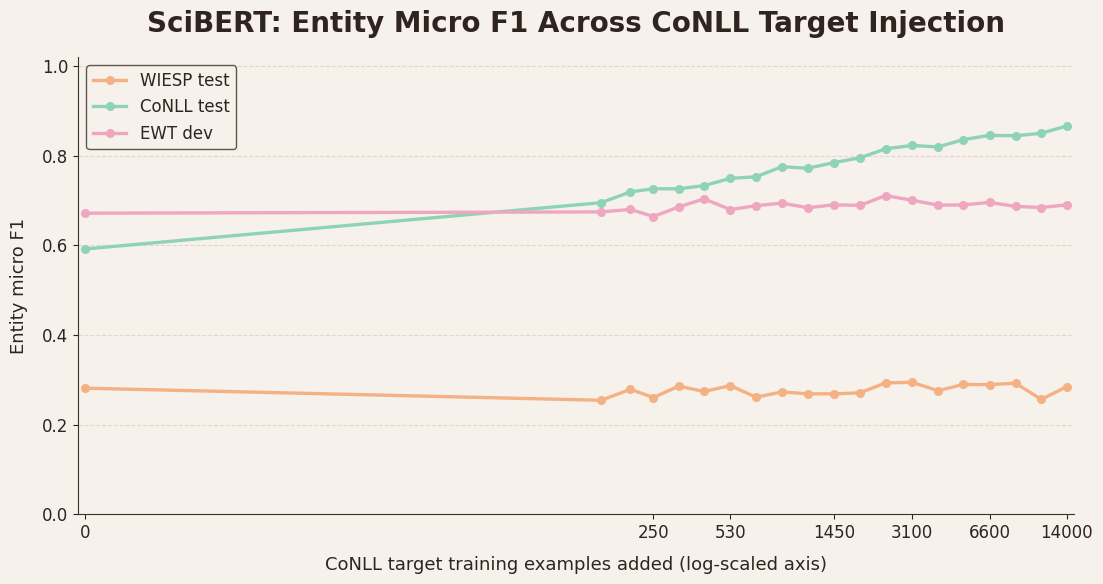

In [9]:
plt.figure(figsize=(11, 6))

for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples_display")
    plt.plot(
        log_x(sub["n_target_examples_display"]),
        sub["entity_f1_micro"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

finish_plot(
    "SciBERT: Entity Micro F1 Across CoNLL Target Injection",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Entity micro F1"
)
apply_log_xaxis_from(summary)
plt.ylim(0, 1.02)
plt.show()


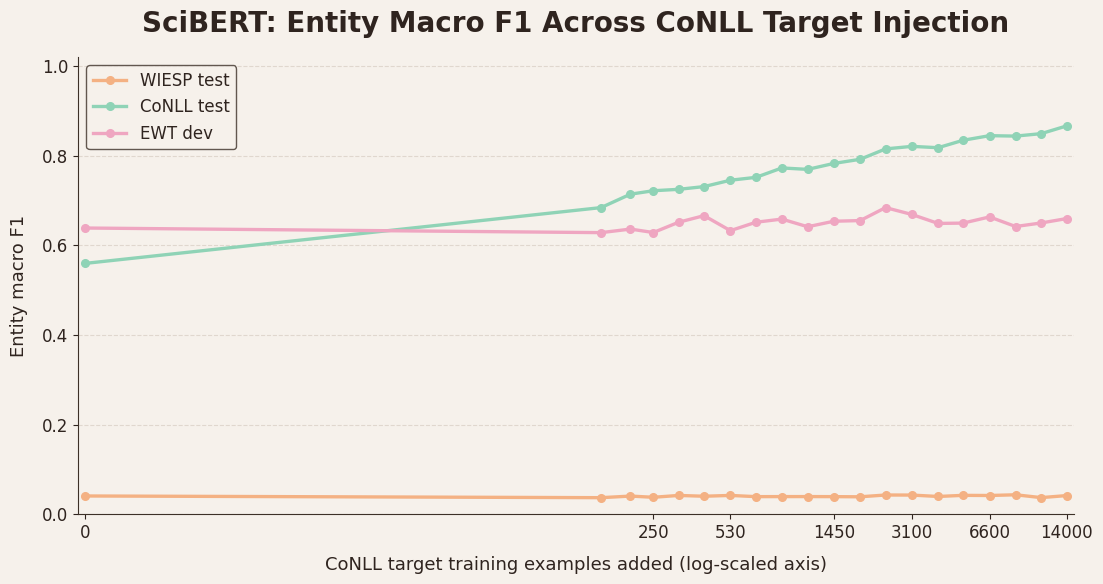

In [10]:
plt.figure(figsize=(11, 6))

for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples_display")
    plt.plot(
        log_x(sub["n_target_examples_display"]),
        sub["entity_f1_macro"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

finish_plot(
    "SciBERT: Entity Macro F1 Across CoNLL Target Injection",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Entity macro F1"
)
apply_log_xaxis_from(summary)
plt.ylim(0, 1.02)
plt.show()


## 4. CoNLL precision, recall, micro F1, macro F1, and token accuracy

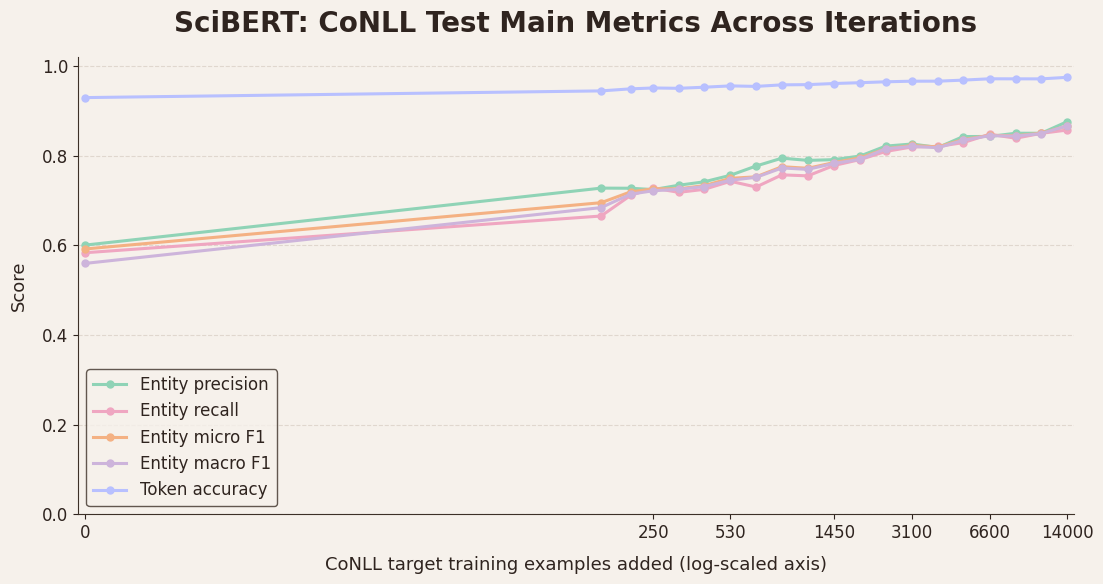

In [11]:
target_metrics = ["entity_precision", "entity_recall", "entity_f1_micro", "entity_f1_macro", "token_acc"]
target_colors = ["#8FD3B6", "#EFA6C1", "#F4B183", "#CDB4DB", "#B8C0FF"]

plt.figure(figsize=(11, 6))

for col, color in zip(target_metrics, target_colors):
    plt.plot(
        log_x(avg_target["n_target_examples_display"]),
        avg_target[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color=color,
        label=METRIC_LABELS.get(col, col)
    )

finish_plot(
    "SciBERT: CoNLL Test Main Metrics Across Iterations",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Score"
)
apply_log_xaxis_from(summary)
plt.ylim(0, 1.02)
plt.show()


## 5. Seed variability around CoNLL micro F1

In [12]:
available_seeds = sorted(summary["seed"].unique())
print("Available seeds:", available_seeds)

if summary["seed"].nunique() > 1:
    target_std = std[std["eval_set"] == "conll_test"].sort_values("n_target_examples_display")
    plot_df = avg_target.sort_values("n_target_examples_display")

    x = log_x(plot_df["n_target_examples_display"])
    y = plot_df["entity_f1_micro"].to_numpy()
    yerr = target_std["entity_f1_micro"].to_numpy()

    plt.figure(figsize=(11, 6))
    plt.plot(x, y, marker="o", linewidth=2.6, markersize=5.5,
             color=DOMAIN_COLORS["conll_test"], label="CoNLL mean micro F1")
    plt.fill_between(x, y - yerr, y + yerr,
                     color=DOMAIN_COLORS["conll_test"], alpha=0.22, linewidth=0, label="±1 seed std")

    finish_plot(
        "SciBERT: CoNLL Micro F1 with Seed Variability",
        xlabel="CoNLL target training examples added (log-scaled axis)",
        ylabel="Entity micro F1"
    )
    apply_log_xaxis_from(summary)
    plt.ylim(max(0, (y - yerr).min() - 0.03), min(1.02, (y + yerr).max() + 0.03))
    plt.show()
else:
    print("Only one seed is available, so seed variability / std bands cannot be calculated.")
    display(avg_target[["iteration", "n_target_examples", "n_target_examples_display", "entity_f1_micro"]].round(4))


Available seeds: [42]
Only one seed is available, so seed variability / std bands cannot be calculated.


,iteration,n_target_examples,n_target_examples_display,entity_f1_micro
1,0,0,0,0.5919
4,1,150,150,0.6951
7,2,200,200,0.7192
10,3,250,250,0.7261
13,4,320,320,0.7260
16,5,410,410,0.7331
19,6,530,530,0.7495
22,7,680,680,0.7528
25,8,875,875,0.7754
28,9,1125,1125,0.7718


## 6. Final iteration comparison across domains

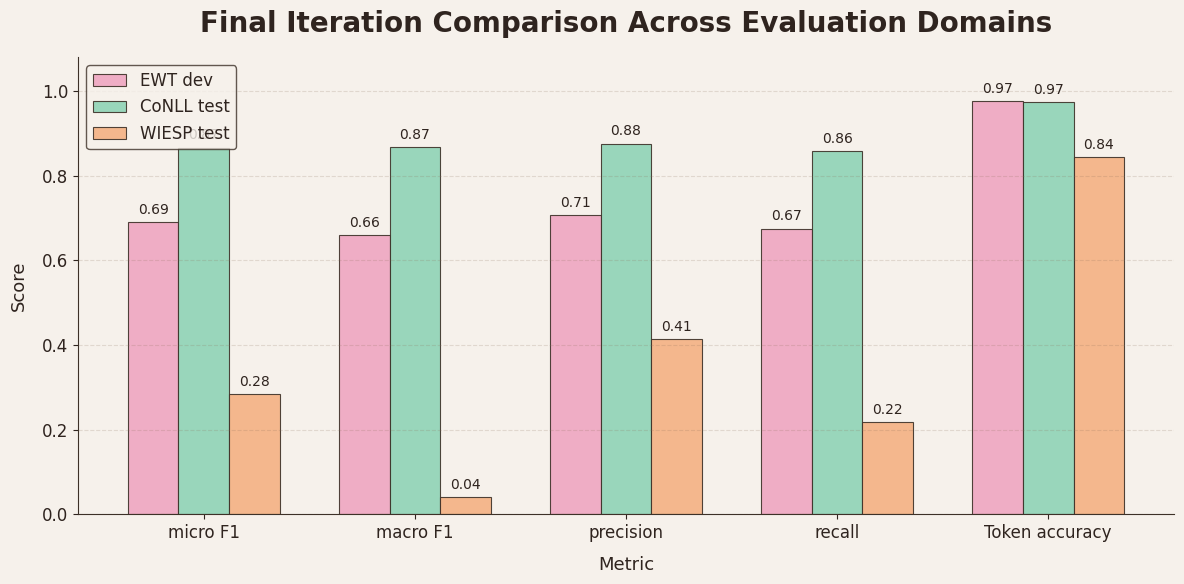

In [13]:
metrics_to_compare = ["entity_f1_micro", "entity_f1_macro", "entity_precision", "entity_recall", "token_acc"]
final_pivot = final_avg.set_index("eval_set")[metrics_to_compare].loc[
    [e for e in ["ewt_dev", "conll_test", "astro_test"] if e in final_avg["eval_set"].values]
]

x = np.arange(len(metrics_to_compare))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))

for i, eval_set in enumerate(final_pivot.index):
    values = final_pivot.loc[eval_set].values.astype(float)
    bars = ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        alpha=0.9,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        edgecolor=EDGE,
        linewidth=0.8,
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )
    add_bar_labels(ax, bars, fmt="{:.2f}", y_offset=0.012)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m].replace("Entity ", "") for m in metrics_to_compare])

finish_plot(
    "Final Iteration Comparison Across Evaluation Domains",
    xlabel="Metric",
    ylabel="Score"
)
plt.ylim(0, 1.08)
plt.show()


## 7. Gain over iteration 0

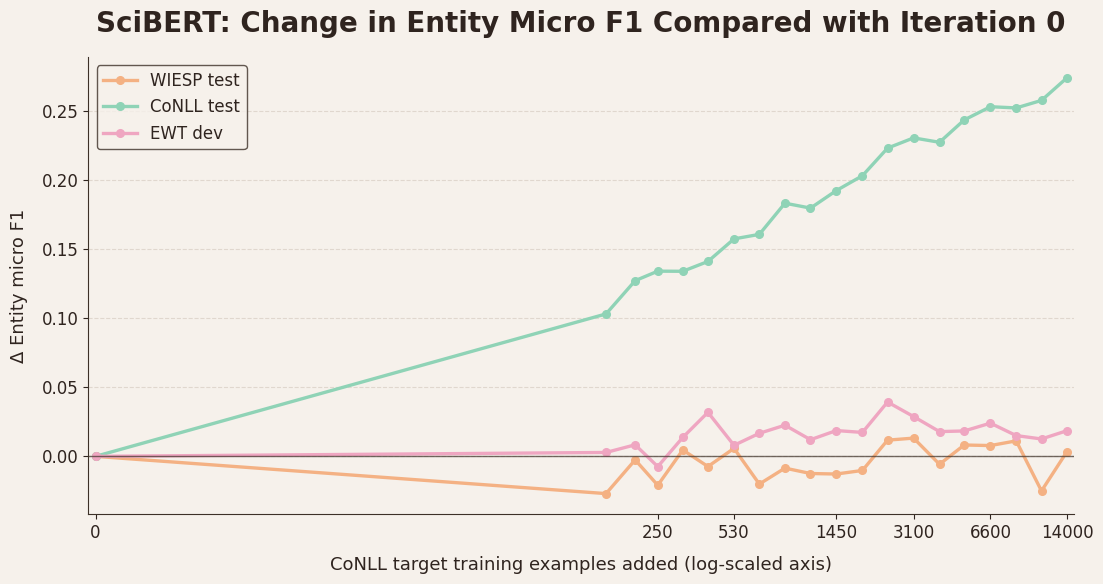

In [14]:
plt.figure(figsize=(11, 6))

for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples_display")
    plt.plot(
        log_x(sub["n_target_examples_display"]),
        sub["delta_f1_vs_iter0"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

plt.axhline(0, color=EDGE, linewidth=1.0, alpha=0.7)

finish_plot(
    "SciBERT: Change in Entity Micro F1 Compared with Iteration 0",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Δ Entity micro F1"
)
apply_log_xaxis_from(summary)
plt.show()


## 8. Per-entity CoNLL performance

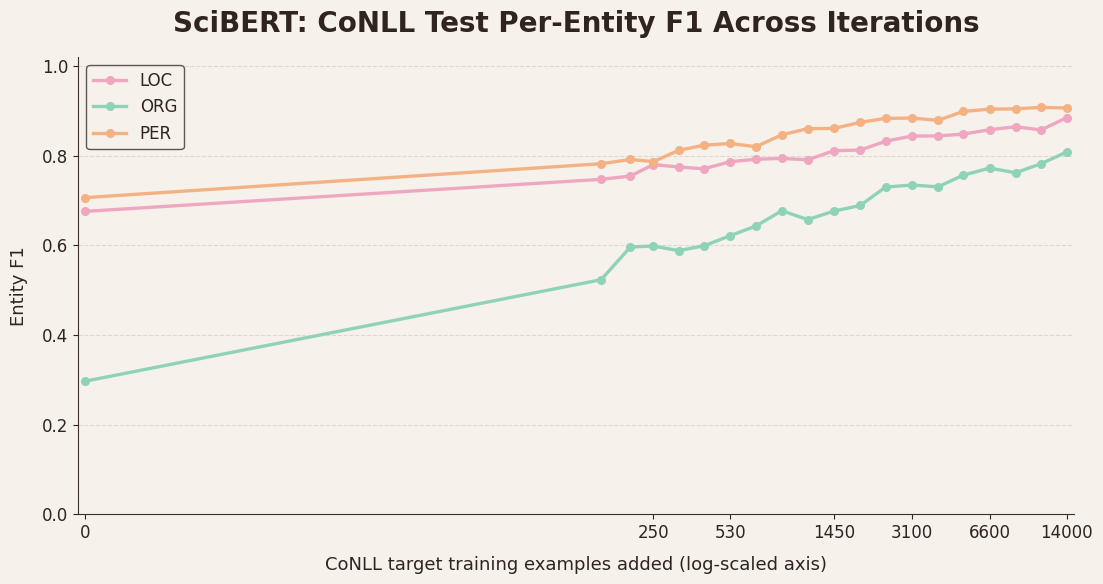

In [15]:
entity_cols = [c for c in ["f1_LOC", "f1_ORG", "f1_PER"] if c in avg_target.columns]
entity_colors = {"f1_LOC": "#EFA6C1", "f1_ORG": "#8FD3B6", "f1_PER": "#F4B183"}

plt.figure(figsize=(11, 6))

for col in entity_cols:
    plt.plot(
        log_x(avg_target["n_target_examples_display"]),
        avg_target[col],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=entity_colors.get(col, "#F4B183"),
        label=col.replace("f1_", "")
    )

finish_plot(
    "SciBERT: CoNLL Test Per-Entity F1 Across Iterations",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Entity F1"
)
apply_log_xaxis_from(summary)
plt.ylim(0, 1.02)
plt.show()


## 9. Precision-recall balance on CoNLL

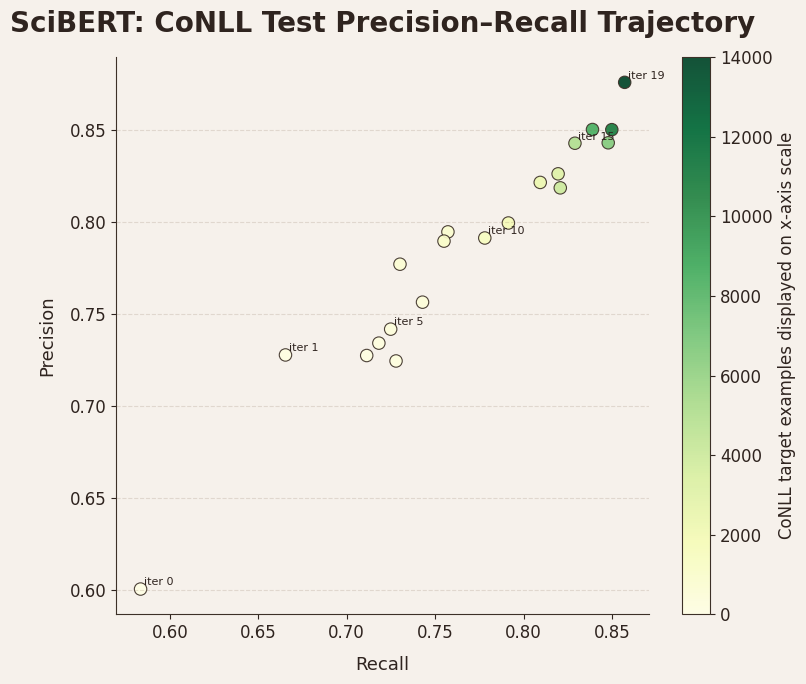

In [16]:
plt.figure(figsize=(8, 7))

sc = plt.scatter(
    avg_target["entity_recall"],
    avg_target["entity_precision"],
    s=80,
    c=avg_target["n_target_examples_display"],
    cmap="Oranges" if "conll_test" == "astro_test" else "YlGn",
    edgecolor=EDGE,
    linewidth=0.8,
    alpha=0.92
)

for _, row in avg_target.iterrows():
    if row["iteration"] in [0, 1, 5, 10, 15, 19]:
        plt.text(
            row["entity_recall"] + 0.002,
            row["entity_precision"] + 0.002,
            f"iter {int(row['iteration'])}",
            fontsize=8,
            color=TEXT
        )

cbar = plt.colorbar(sc)
cbar.set_label("CoNLL target examples displayed on x-axis scale", color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.get_yticklabels(), color=TEXT)

finish_plot(
    "SciBERT: CoNLL Test Precision–Recall Trajectory",
    xlabel="Recall",
    ylabel="Precision",
    legend=False
)
plt.show()


## 10. Efficiency and resource analysis

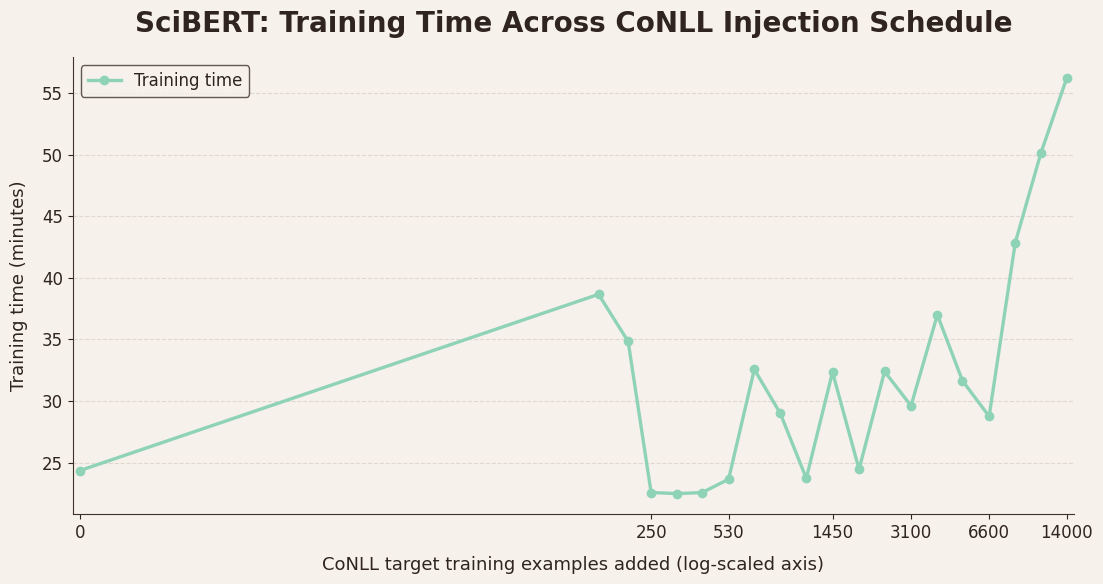

In [17]:
resource_cols = ["seed", "iteration", "n_target_examples", "n_target_examples_display", "train_time_sec", "best_epoch", "peak_gpu_mem_mb"]
resource_cols = [c for c in resource_cols if c in summary.columns]

resource = summary[resource_cols].drop_duplicates()

resource_avg = resource.groupby(["iteration", "n_target_examples", "n_target_examples_display"], as_index=False).agg(
    train_time_sec_mean=("train_time_sec", "mean"),
    best_epoch_mean=("best_epoch", "mean"),
    peak_gpu_mem_mb_mean=("peak_gpu_mem_mb", "mean"),
)

plt.figure(figsize=(11, 6))

plt.plot(
    log_x(resource_avg["n_target_examples_display"]),
    resource_avg["train_time_sec_mean"] / 60,
    marker="o",
    linewidth=2.4,
    color="#8FD3B6",
    label="Training time"
)

finish_plot(
    "SciBERT: Training Time Across CoNLL Injection Schedule",
    xlabel="CoNLL target training examples added (log-scaled axis)",
    ylabel="Training time (minutes)"
)
apply_log_xaxis_from(summary)
plt.show()


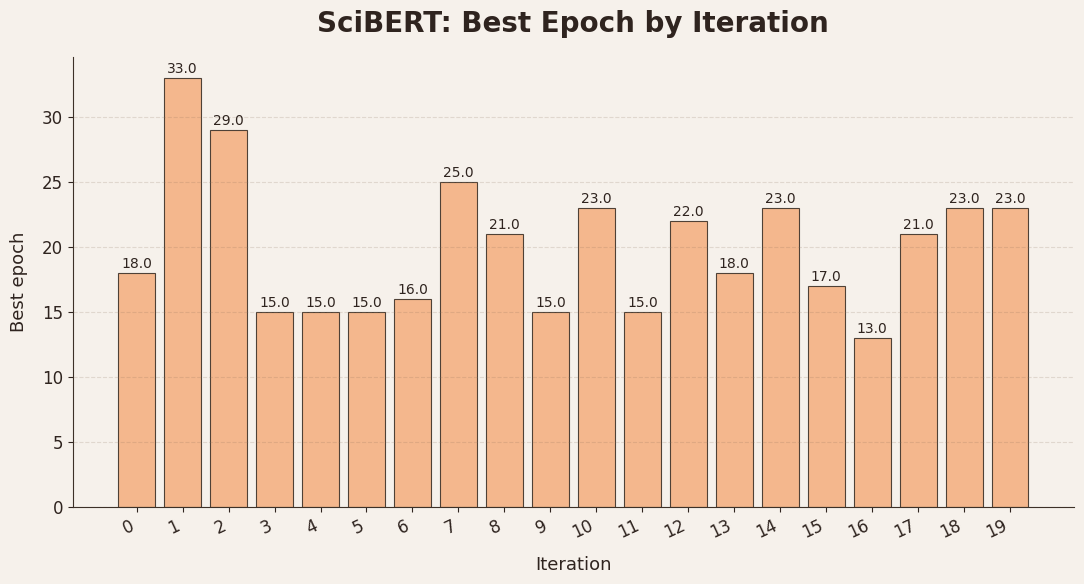

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    resource_avg["iteration"].astype(str),
    resource_avg["best_epoch_mean"],
    color="#F4B183",
    alpha=0.9,
    edgecolor=EDGE,
    linewidth=0.8
)

add_bar_labels(ax, bars, fmt="{:.1f}", y_offset=0.2)

finish_plot(
    "SciBERT: Best Epoch by Iteration",
    xlabel="Iteration",
    ylabel="Best epoch",
    legend=False,
    rotate_x=True
)
plt.show()


## 11. Automatic result tables for the report

In [19]:
table_cols = [
    "eval_set", "n_target_examples", "n_target_examples_display",
    "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall",
    "token_acc", "token_f1", "eval_loss"
]
table_cols = [c for c in table_cols if c in final_avg.columns]

final_table = final_avg[table_cols].copy()
final_table["eval_set"] = final_table["eval_set"].map(DOMAIN_LABELS)

final_table.round(4)


,eval_set,n_target_examples,n_target_examples_display,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,token_f1,eval_loss
57,WIESP test,14000,14000,0.2849,0.0420,0.4132,0.2174,0.8447,0.0841,3.3994
58,CoNLL test,14000,14000,0.8663,0.8665,0.8756,0.8571,0.9747,0.9135,0.1556
59,EWT dev,14000,14000,0.6903,0.6598,0.7064,0.6749,0.9750,0.7946,0.1522


In [20]:
progression_cols = [
    "iteration", "n_target_examples", "n_target_examples_display", "target_fraction",
    "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall",
    "token_acc", "token_f1", "eval_loss"
]
progression_cols = [c for c in progression_cols if c in avg_target.columns]

target_progression = avg_target[progression_cols].round(4)
target_progression


,iteration,n_target_examples,n_target_examples_display,target_fraction,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,token_f1,eval_loss
1,0,0,0,0.0000,0.5919,0.5597,0.6005,0.5835,0.9295,0.7201,0.5398
4,1,150,150,0.0118,0.6951,0.6842,0.7276,0.6654,0.9444,0.7960,0.3890
7,2,200,200,0.0157,0.7192,0.7141,0.7273,0.7113,0.9490,0.8176,0.2956
10,3,250,250,0.0195,0.7261,0.7218,0.7243,0.7279,0.9509,0.8237,0.3122
13,4,320,320,0.0249,0.7260,0.7249,0.7340,0.7182,0.9502,0.8275,0.2872
16,5,410,410,0.0317,0.7331,0.7310,0.7416,0.7248,0.9526,0.8340,0.2959
19,6,530,530,0.0405,0.7495,0.7452,0.7563,0.7428,0.9556,0.8413,0.2782
22,7,680,680,0.0514,0.7528,0.7516,0.7769,0.7301,0.9544,0.8399,0.2743
25,8,875,875,0.0652,0.7754,0.7726,0.7944,0.7572,0.9579,0.8530,0.2531
28,9,1125,1125,0.0823,0.7718,0.7694,0.7894,0.7550,0.9584,0.8544,0.2718
